In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
from petsc4py import PETSc

from dolfinx import mesh, fem
from dolfinx.fem import petsc
import ufl

from tqdm import tqdm, trange

/root/projects/pde_scattering/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ----------------------------
# 1. mesh
# ----------------------------
# Start smaller than 512x512. FEM at 512x512 is possible but not a good first debugging target.
nx, ny = 128, 128
domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny)

In [3]:
# ----------------------------
# 2. function space
# ----------------------------
V = fem.functionspace(domain, ("CG", 1))

A = fem.Function(V, name="A")
B = fem.Function(V, name="B")

A_n = fem.Function(V, name="A_n")
B_n = fem.Function(V, name="B_n")

v = ufl.TestFunction(V)
u = ufl.TrialFunction(V)

In [4]:
# ----------------------------
# 3. parameters
# ----------------------------
D_A = 0.05
D_B = 0.03

f_low, f_high = 0.035, 0.10
k_low, k_high = 0.055, 0.07

dt = 0.5
nsteps = 5001
save_every = 100

In [5]:
# ----------------------------
# 4. define spatial parameter fields
# ----------------------------
f_fun = fem.Function(V, name="f")
k_fun = fem.Function(V, name="k")

# coordinates of interpolation points
def f_expr(x):
    # x[0] in [0,1]
    return f_low + (f_high - f_low) * x[0]

def k_expr(x):
    # x[1] in [0,1]
    return k_low + (k_high - k_low) * x[1]

f_fun.interpolate(f_expr)
k_fun.interpolate(k_expr)

In [6]:
# ----------------------------
# 5. initial condition
# ----------------------------
# Match old notebook qualitatively:
# A = 1 everywhere
# B = 0, with random seeded regions

# A_n.x.array[:] = 1.0
# B_n.x.array[:] = 0.0

# rng = np.random.default_rng(42)
# coords = V.tabulate_dof_coordinates()
# xy = coords[:, :2]

# # simple random threshold field on DOFs
# rand_field = rng.random(len(B_n.x.array))
# B_n.x.array[rand_field > 0.6] = 1.0

# A.x.array[:] = A_n.x.array
# B.x.array[:] = B_n.x.array

from scipy.ndimage import gaussian_filter
rng = np.random.default_rng(42)

A_n.x.array[:] = 1.0
B_n.x.array[:] = 0.0

rand0 = rng.random((nx + 1, ny + 1))
rand_smooth = gaussian_filter(rand0, sigma=2)

# map nodal coordinates to structured grid indices
coords = V.tabulate_dof_coordinates()[:, :2]
ix = np.clip(np.round(coords[:, 0] * nx).astype(int), 0, nx)
iy = np.clip(np.round(coords[:, 1] * ny).astype(int), 0, ny)

vals = rand_smooth[ix, iy]
B_n.x.array[vals > 0.6] = 1.0

A.x.array[:] = A_n.x.array
B.x.array[:] = B_n.x.array

In [7]:
# ----------------------------
# 6. weak forms for semi-implicit update
# ----------------------------
# A-update:
# (A^{n+1} - A^n)/dt = D_A ΔA^{n+1} - A^n (B^n)^2 + f(1 - A^n)
#
# B-update:
# (B^{n+1} - B^n)/dt = D_B ΔB^{n+1} + A^n (B^n)^2 - (k+f) B^n

a_A = (u * v + dt * D_A * ufl.dot(ufl.grad(u), ufl.grad(v))) * ufl.dx
L_A = (A_n + dt * (-A_n * B_n**2 + f_fun * (1.0 - A_n))) * v * ufl.dx

a_B = (u * v + dt * D_B * ufl.dot(ufl.grad(u), ufl.grad(v))) * ufl.dx
L_B = (B_n + dt * (A_n * B_n**2 - (k_fun + f_fun) * B_n)) * v * ufl.dx

In [8]:
# ----------------------------
# 7. reusable matrices / solvers
# ----------------------------
A_mat_form = fem.form(a_A)
B_mat_form = fem.form(a_B)

A_rhs_form = fem.form(L_A)
B_rhs_form = fem.form(L_B)

A_mat = petsc.assemble_matrix(A_mat_form)
A_mat.assemble()

B_mat = petsc.assemble_matrix(B_mat_form)
B_mat.assemble()

ksp_A = PETSc.KSP().create(domain.comm)
ksp_A.setOperators(A_mat)
ksp_A.setType("cg")
ksp_A.getPC().setType("hypre")

ksp_B = PETSc.KSP().create(domain.comm)
ksp_B.setOperators(B_mat)
ksp_B.setType("cg")
ksp_B.getPC().setType("hypre")

In [9]:
# ----------------------------
# 8. updater
# ----------------------------
def step_gray_scott():
    # assemble RHS for A
    b_A = petsc.assemble_vector(A_rhs_form)
    b_A.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    ksp_A.solve(b_A, A.x.petsc_vec)
    A.x.scatter_forward()

    # assemble RHS for B
    b_B = petsc.assemble_vector(B_rhs_form)
    b_B.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    ksp_B.solve(b_B, B.x.petsc_vec)
    B.x.scatter_forward()

    # optional clipping
    A.x.array[:] = np.clip(A.x.array, 0.0, 1.5)
    B.x.array[:] = np.clip(B.x.array, 0.0, 1.5)

    # advance state
    A_n.x.array[:] = A.x.array
    B_n.x.array[:] = B.x.array

In [10]:
# ----------------------------
# 9. quick plotting helper
# ----------------------------
def plot_field(fun, title=None, cmap="viridis"):
    coords = V.tabulate_dof_coordinates()[:, :2]
    vals = fun.x.array.copy()

    if domain.comm.rank == 0:
        plt.figure(figsize=(6, 5))
        plt.tripcolor(coords[:, 0], coords[:, 1], vals, shading="gouraud", cmap=cmap)
        plt.colorbar()
        if title:
            plt.title(title)
        plt.gca().set_aspect("equal")
        plt.tight_layout()
        plt.show()

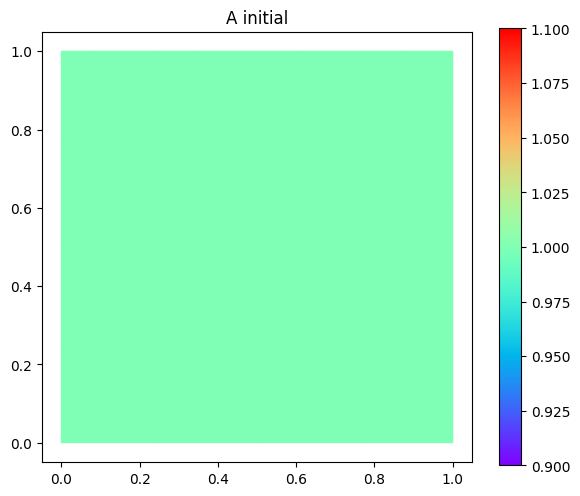

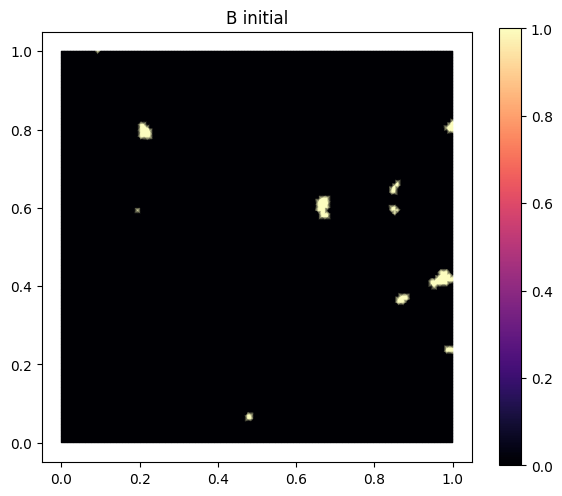

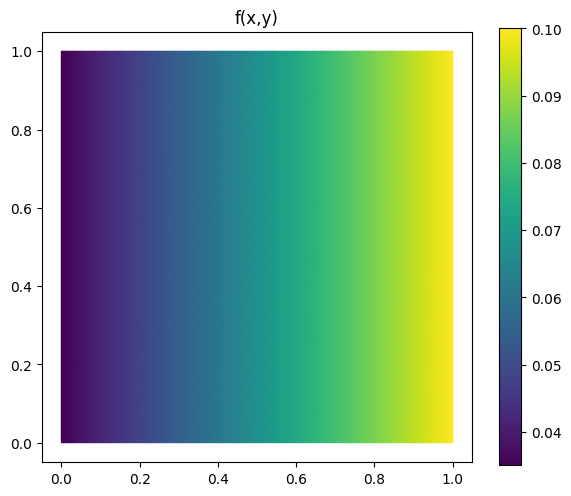

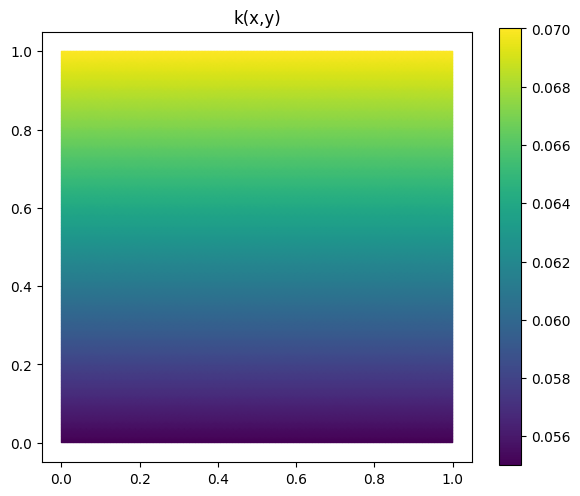

In [11]:
plot_field(A_n, "A initial", cmap="rainbow")
plot_field(B_n, "B initial", cmap="magma")
plot_field(f_fun, "f(x,y)")
plot_field(k_fun, "k(x,y)")

In [12]:
# ----------------------------
# 10. time loop
# ----------------------------
snapshots_A = []
snapshots_B = []
times = []

for t in trange(nsteps + 1):
    if t % save_every == 0:
        snapshots_A.append(A_n.x.array.copy())
        snapshots_B.append(B_n.x.array.copy())
        times.append(t)

    step_gray_scott()

  0%|          | 0/5002 [00:00<?, ?it/s]

100%|██████████| 5002/5002 [02:43<00:00, 30.52it/s] 


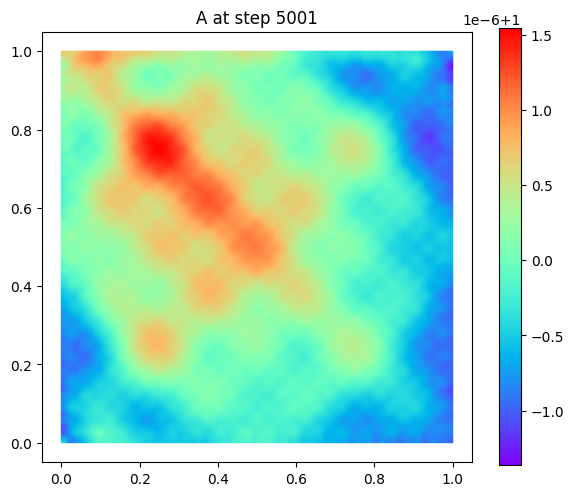

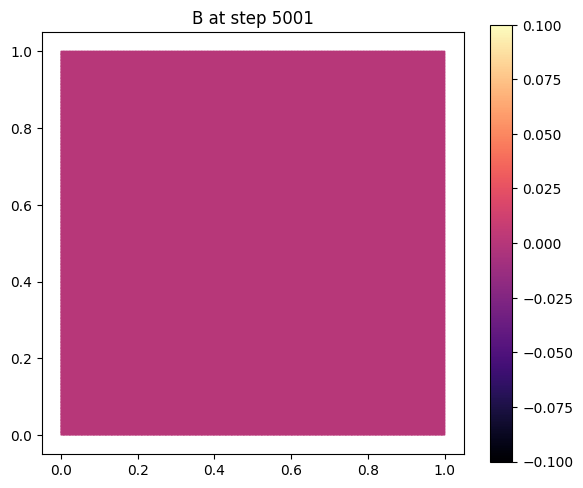

In [13]:
plot_field(A_n, f"A at step {nsteps}", cmap="rainbow")
plot_field(B_n, f"B at step {nsteps}", cmap="magma")